In [100]:
import pandas as pd 
import matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import utils
pd.options.display.float_format = '{:.1f}'.format


In [101]:
def scaling():
    pass

In [102]:
df_gpu = pd.read_csv("result_gpu.csv")



### Check the Outliers

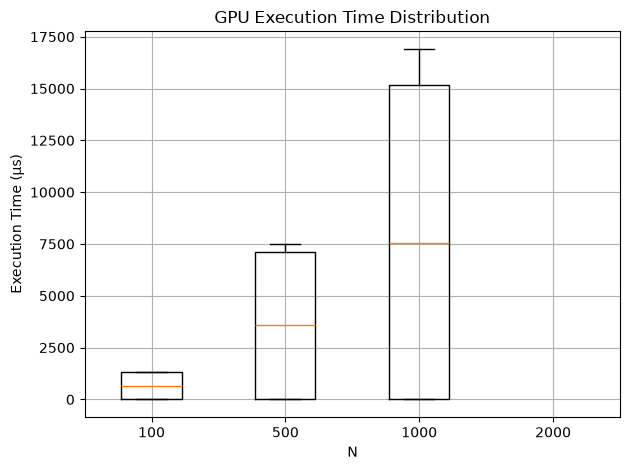

In [103]:
N_values=[100,500,1000,2000]
plt.boxplot(
    [df_gpu[df_gpu['N'] == n]['time_us'] for n in N_values],
    tick_labels=N_values
)

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("GPU Execution Time Distribution")
plt.grid(True)

plt.tight_layout()
plt.show()

### Remove the Outliers Using IQR :

In [104]:
groupby = "N"
var_to_compute = "time_us" 
clean_data_gpu = utils.remove_outliers(df_gpu , groupby , var_to_compute )
n_gpu = len(clean_data_gpu)

removed_percentages_gpu = 0 if len(df_gpu) == 0 else ( (len(df_gpu) - n_gpu) / len(df_gpu) ) * 100


In [105]:
# GPU
print("GPU VERSION : ")
print(f"Original Samples : {len(df_gpu)}" )
print(f"Clean Samples : {n_gpu}")
print(f"Removed         : {removed_percentages_gpu:.2f} %")

GPU VERSION : 
Original Samples : 120
Clean Samples : 120
Removed         : 0.00 %


In [106]:
original_count = df_gpu.groupby('N').size()
clean_count = clean_data_gpu.groupby('N').size()

outlier_stats = pd.DataFrame({
    'original': original_count,
    'clean': clean_count
})

outlier_stats['removed'] = (
    outlier_stats['original'] -
    outlier_stats['clean']
)

outlier_stats['removed_%'] = (
    outlier_stats['removed'] /
    outlier_stats['original'] * 100
)

outlier_stats = outlier_stats.reset_index()
outlier_stats


,N,original,clean,removed,removed_%
0,100,40,40,0,0.0
1,500,40,40,0,0.0
2,1000,40,40,0,0.0


### Statistics


In [107]:
groupby = "N"
var_to_compute = "time_us" 
stats_data =  utils.stats( clean_data_gpu , groupby, var_to_compute)
stats_data = stats_data.reset_index()
stats_data

KeyError: 'std'

In [82]:
# median_execution_time():

plt.plot(stats_data['N'], stats_data['median'], color='green', marker='o', label='median')
plt.plot(stats_data['N'], stats_data['mean'], color='red', linestyle='--', label='mean')

plt.xlabel("N")
plt.ylabel("Execution Time (µs)")
plt.title("Execution Time (µs)")
plt.grid(True)
plt.legend() 
plt.show()

KeyError: 'N'

In [ ]:
# execution_time_log():
plt.errorbar(
    stats_data['N'],
    stats_data['mean'],
    yerr=stats_data['std'],
    fmt='-',
    capsize=5
)

plt.scatter(
    stats_data['N'],
    stats_data['mean'],
    color='red',
    zorder=3
)

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Execution time (µs)")
plt.title("Execution Time vs N (Log Scale)")
plt.grid(True)

plt.show()